# Notebook 4: Building a database of putative MDM2 binders

In this part of the course, you will apply the learned concepts of simularity searching, clustering and machine learning to build a small molecule dataset of putative MDM2 binders. We will query the ChEMBL database for MDM2 binders and build a model around that to interrogate vendor databases.


## Retrieving MDM2 binders from ChEMBL

In [1]:
# Load the library that lets you access data from the ChEMBL database
# Load pandas
!pip install chembl_webresource_client pandas tqdm

In [2]:
import pandas as pd
from tqdm.auto import tqdm
from chembl_webresource_client.new_client import new_client

TARGET_ID = "CHEMBL5023"  # human MDM2

# Interfaces to different types of ChEMBL data (activities, molecules and assays)
# Connect to ChEMBL → focus on MDM2 → access activity, molecule, and assay data
activity = new_client.activity
molecule = new_client.molecule
assay = new_client.assay

/opt/anaconda3/lib/python3.13/site-packages/chembl_webresource_client/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __version__ = __import__('pkg_resources').get_distribution('chembl_webresource_client').version


In [3]:
# Retrieve bioactivities for human MDM2
# Give me potency data for MDM2, using standard measurements, all in the same units
activities = activity.filter(
    target_chembl_id=TARGET_ID,
    standard_type__in=["IC50", "Ki", "Kd", "EC50"],
    standard_units="nM"
).only( 
    "molecule_chembl_id",   # which compound
    "assay_chembl_id",      # which experiment
    "standard_type",        # IC50, Ki, etc
    "standard_relation",    # symbols like =, <, >
    "standard_value",       # numerical result like 50 nM
    "standard_units",       # the units
    "pchembl_value",        # normalized/log-transformed potency
    "assay_description",    # what kind of test was done
    "document_chembl_id"    # reference to the paper
)

# Fetch with progress bar
records = [x for x in tqdm(activities, desc="Downloading MDM2 activities")]

# activities is not yet a normal list — it’s a lazy query result, hence by
# converting to a list the data are actually fetched
df = pd.DataFrame(list(activities))
print(df.shape)
print(df.head())

(6984, 13)
  assay_chembl_id                                  assay_description  \
0    CHEMBL874553  Binding affinity between MDM2 and p53 protein ...   
1    CHEMBL874553  Binding affinity between MDM2 and p53 protein ...   
2    CHEMBL874553  Binding affinity between MDM2 and p53 protein ...   
3    CHEMBL874553  Binding affinity between MDM2 and p53 protein ...   
4    CHEMBL874553  Binding affinity between MDM2 and p53 protein ...   

  document_chembl_id molecule_chembl_id pchembl_value relation  \
0      CHEMBL1143503       CHEMBL178578          5.77        =   
1      CHEMBL1143503       CHEMBL361103          6.70        =   
2      CHEMBL1143503       CHEMBL182051          4.52        =   
3      CHEMBL1143503       CHEMBL360540          4.89        =   
4      CHEMBL1143503       CHEMBL427316          5.44        =   

  standard_relation standard_type standard_units standard_value  type units  \
0                 =          IC50             nM         1700.0  IC50    uM   
1

In [4]:
# Inspect the returned values
print(len(df))
df

6984


,assay_chembl_id,assay_description,document_chembl_id,molecule_chembl_id,pchembl_value,relation,standard_relation,standard_type,standard_units,standard_value,type,units,value
0,CHEMBL874553,Binding affinity between MDM2 and p53 protein ...,CHEMBL1143503,CHEMBL178578,5.77,=,=,IC50,nM,1700.0,IC50,uM,1.7
1,CHEMBL874553,Binding affinity between MDM2 and p53 protein ...,CHEMBL1143503,CHEMBL361103,6.70,=,=,IC50,nM,200.0,IC50,uM,0.2
2,CHEMBL874553,Binding affinity between MDM2 and p53 protein ...,CHEMBL1143503,CHEMBL182051,4.52,=,=,IC50,nM,30000.0,IC50,uM,30.0
3,CHEMBL874553,Binding affinity between MDM2 and p53 protein ...,CHEMBL1143503,CHEMBL360540,4.89,=,=,IC50,nM,13000.0,IC50,uM,13.0
4,CHEMBL874553,Binding affinity between MDM2 and p53 protein ...,CHEMBL1143503,CHEMBL427316,5.44,=,=,IC50,nM,3600.0,IC50,uM,3.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6979,CHEMBL5739243,Enzyme Level Activity Assay: In the present di...,CHEMBL5729689,CHEMBL6014971,9.62,=,=,IC50,nM,0.24,IC50,nM,0.24
6980,CHEMBL5739243,Enzyme Level Activity Assay: In the present di...,CHEMBL5729689,CHEMBL5805098,9.16,=,=,IC50,nM,0.69,IC50,nM,0.69
6981,CHEMBL5739243,Enzyme Level Activity Assay: In the present di...,CHEMBL5729689,CHEMBL6045300,8.54,=,=,IC50,nM,2.86,IC50,nM,2.86
6982,CHEMBL5739243,Enzyme Level Activity Assay: In the present di...,CHEMBL5729689,CHEMBL6055628,9.60,=,=,IC50,nM,0.25,IC50,nM,0.25


In [5]:
# Converts some columns into numeric format (floats/integers)
# Even though standard_value should be numeric, in real datasets (like from ChEMBL), you often get messy entries
df["standard_value"] = pd.to_numeric(df["standard_value"], errors="coerce")
df["pchembl_value"] = pd.to_numeric(df["pchembl_value"], errors="coerce")

In [6]:
# Removing rows with missing critical data
# If molecule_chembl_id is missing: you don't know which compound it is
# If standard_value is missing: no usable measurement
df = df.dropna(subset=["molecule_chembl_id", "standard_value"])
df = df[df["standard_relation"].isin(["=", "<", "<="])]

In [7]:
# Focus on likely MDM2-p53 PPI assays
# Do text-based filtering to keep only assays related to protein–protein interactions (PPI)
ppi_keywords = [
    "p53", "p53-mdm2", "mdm2-p53", "protein interaction",
    "protein-protein", "ppi", "fluorescence polarization",
    "fp", "htrf", "alphascreen", "peptide binding"
]

# Joins keywords into a regex pattern: "any of these keywords"
pattern = "|".join(ppi_keywords)
print(pattern)

# Filter the dataframe
df_ppi = df[
    df["assay_description"]
    .fillna("")                            # Replaces missing descriptions with empty strings
    .str.lower()                           # Makes matching case-insensitive
    .str.contains(pattern, regex=True)     # Checks if the description contains any keyword
].copy()

p53|p53-mdm2|mdm2-p53|protein interaction|protein-protein|ppi|fluorescence polarization|fp|htrf|alphascreen|peptide binding


In [8]:
# Reconnect again to the ChEMBL db with molecule as the endpoint for compound-level data
from chembl_webresource_client.new_client import new_client
import pandas as pd

molecule = new_client.molecule

unique_mols = (
    df_ppi["molecule_chembl_id"]
    .dropna()     # remove missing values
    .unique()     # remove dupliactes
    .tolist()     # convert to Python list
)

molecules = molecule.filter(
    molecule_chembl_id__in=unique_mols    # match and ID in this list
).only(
    "molecule_chembl_id",      # ID
    "pref_name",               # compound name
    "molecule_structures",     # contains SMILES
    "max_phase",               # drug development stage
    "molecule_type"            # usually "small molecule"
)

# Fetch the lazy query from above into a list and convert to a dataframe
# molecule_structures is a dictionary like {"canonical_smiles": "CCO", ...}
mol_list = []
for mol in tqdm(molecules, total=len(unique_mols), desc="Fetching molecules"):
    mol_list.append(mol)
mol_df = pd.DataFrame(mol_list)

# Extract SMILES and put it into the dataframe
mol_df["canonical_smiles"] = mol_df["molecule_structures"].apply(
    lambda x: (x or {}).get("canonical_smiles")
)

# Remove the messy nested column
mol_df = mol_df.drop(columns=["molecule_structures"])

Fetching molecules:   0%|          | 0/4643 [00:00<?, ?it/s]

In [9]:
mol_df

,max_phase,molecule_chembl_id,molecule_type,pref_name,canonical_smiles
0,None,CHEMBL8320,Small molecule,BENZOQUINONE,O=C1C=CC(=O)C=C1
1,4.0,CHEMBL53,Small molecule,APOMORPHINE,CN1CCc2cccc3c2[C@H]1Cc1ccc(O)c(O)c1-3
2,None,CHEMBL416288,Small molecule,(S)APOMORPHINE,CN1CCc2cccc3c2[C@@H]1Cc1ccc(O)c(O)c1-3
3,None,CHEMBL405395,Protein,None,CSCC[C@H](NC(=O)[C@H](Cc1ccccc1)NC(C)=O)C(=O)N...
4,None,CHEMBL361103,Small molecule,None,O=C(O)[C@H](c1ccc(Cl)cc1)N1C(=O)c2cc(I)ccc2NC(...
...,...,...,...,...,...
4638,None,CHEMBL6065049,None,None,CC[C@@](O)(c1cc(F)c2c(c1)C(=O)N(Cc1ccc(Cl)cc1)...
4639,None,CHEMBL6065079,None,None,CC(=O)N1CCN(c2nc3nc(-c4noc(=O)[nH]4)nc(N[C@H](...
4640,None,CHEMBL6065243,None,None,Cc1cccc(-c2nc3nc(C(=O)O)nc(NC4CCCCC4)c3n2Cc2cc...
4641,None,CHEMBL6065452,None,None,C[C@H]1CC[C@H](Cn2c(C3CC3)nc3nc(-c4noc(=O)[nH]...


In [9]:
# Merge molecule information
merged = df_ppi.merge(mol_df, on="molecule_chembl_id", how="left")
merged

,assay_chembl_id,assay_description,document_chembl_id,molecule_chembl_id,pchembl_value,relation,standard_relation,standard_type,standard_units,standard_value,type,units,value,max_phase,molecule_type,pref_name,canonical_smiles
0,CHEMBL874553,Binding affinity between MDM2 and p53 protein ...,CHEMBL1143503,CHEMBL178578,5.77,=,=,IC50,nM,1700.00,IC50,uM,1.7,None,Small molecule,None,O=C(O)[C@H](c1ccccc1)N1C(=O)c2cc(I)ccc2NC(=O)[...
1,CHEMBL874553,Binding affinity between MDM2 and p53 protein ...,CHEMBL1143503,CHEMBL361103,6.70,=,=,IC50,nM,200.00,IC50,uM,0.2,None,Small molecule,None,O=C(O)[C@H](c1ccc(Cl)cc1)N1C(=O)c2cc(I)ccc2NC(...
2,CHEMBL874553,Binding affinity between MDM2 and p53 protein ...,CHEMBL1143503,CHEMBL182051,4.52,=,=,IC50,nM,30000.00,IC50,uM,30.0,None,Small molecule,None,C[C@H](c1ccc(Cl)cc1)N(C(=O)/C=C/c1ccccc1)[C@H]...
3,CHEMBL874553,Binding affinity between MDM2 and p53 protein ...,CHEMBL1143503,CHEMBL360540,4.89,=,=,IC50,nM,13000.00,IC50,uM,13.0,None,Small molecule,None,C[C@H](c1ccc(Cl)cc1)N1C(=O)C=C(c2ccccc2)N(CCCC...
4,CHEMBL874553,Binding affinity between MDM2 and p53 protein ...,CHEMBL1143503,CHEMBL427316,5.44,=,=,IC50,nM,3600.00,IC50,uM,3.6,None,Small molecule,None,C[C@H](c1ccc(Cl)cc1)N1C(=O)C=C(c2ccccc2Br)N(CC...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5927,CHEMBL5739243,Enzyme Level Activity Assay: In the present di...,CHEMBL5729689,CHEMBL6014971,9.62,=,=,IC50,nM,0.24,IC50,nM,0.24,None,None,None,COc1ncc(-c2nc3c(n2C(C)C)[C@H](c2ccc(Cl)cc2)N(c...
5928,CHEMBL5739243,Enzyme Level Activity Assay: In the present di...,CHEMBL5729689,CHEMBL5805098,9.16,=,=,IC50,nM,0.69,IC50,nM,0.69,None,None,None,COc1ncc(-c2nc3c(n2C(C)C)[C@H](c2ccc(Cl)cc2)N(c...
5929,CHEMBL5739243,Enzyme Level Activity Assay: In the present di...,CHEMBL5729689,CHEMBL6045300,8.54,=,=,IC50,nM,2.86,IC50,nM,2.86,None,None,None,COc1ncc(-c2nc3c(n2C(C)C)[C@@H](c2ccc(Cl)cc2)N(...
5930,CHEMBL5739243,Enzyme Level Activity Assay: In the present di...,CHEMBL5729689,CHEMBL6055628,9.60,=,=,IC50,nM,0.25,IC50,nM,0.25,None,None,None,COc1ncc(-c2nc3c(n2C(C)C)[C@@H](c2ccc(Cl)cc2)N(...


In [10]:
# Deduplicate: keep best potency per compound
best = (
    merged.sort_values("pchembl_value", ascending=False)   # Sort by potency
    .groupby("molecule_chembl_id", as_index=False)         # Group by molecule
    .first()                                               # Take first row in each group (= best potency)
)
best.sort_values("pchembl_value", ascending=False).head(10)  # Show top-10 compounds

,molecule_chembl_id,assay_chembl_id,assay_description,document_chembl_id,pchembl_value,relation,standard_relation,standard_type,standard_units,standard_value,type,units,value,max_phase,molecule_type,pref_name,canonical_smiles
982,CHEMBL3653245,CHEMBL3705464,Time Resolved Fluorescence Energy Transfer (TR...,CHEMBL3639025,10.40,=,=,IC50,nM,0.040,IC50,nM,0.04,None,Small molecule,None,COc1ccc(CO)cc1-c1nc2c(n1C(C)C)[C@H](c1ccc(Cl)c...
2602,CHEMBL4463050,CHEMBL4353006,Inhibition of p53 protein binding to MDM2 in h...,CHEMBL4350977,10.35,=,=,Ki,nM,0.045,Ki,nM,0.045,None,Unknown,None,CC(C)[C@H](N1C(=O)[C@@H](CC(=O)O)C[C@@H](c2ccc...
1142,CHEMBL3657031,CHEMBL3705464,Time Resolved Fluorescence Energy Transfer (TR...,CHEMBL3639025,10.30,=,=,IC50,nM,0.050,IC50,nM,0.05,None,Small molecule,None,COc1ccc(C(=O)NCCO)cc1-c1nc2c(n1C(C)C)[C@H](c1c...
1235,CHEMBL3657124,CHEMBL3705464,Time Resolved Fluorescence Energy Transfer (TR...,CHEMBL3639025,10.23,=,=,IC50,nM,0.059,IC50,nM,0.059,None,Small molecule,None,COC[C@@H](C)n1c(-c2cnc(N(C)C)nc2OC)nc2c1[C@H](...
512,CHEMBL3318761,CHEMBL3370341,Binding affinity to human GST-thrombin-tagged ...,CHEMBL3351847,10.23,=,=,IC50,nM,0.059,IC50,nM,0.059,None,Small molecule,None,C[C@]1(CC(=O)O)C[C@H](c2cccc(Cl)c2)[C@@H](c2cc...
534,CHEMBL3318783,CHEMBL3370341,Binding affinity to human GST-thrombin-tagged ...,CHEMBL3351847,10.23,=,=,IC50,nM,0.059,IC50,nM,0.059,None,Small molecule,None,CC(C)(C)[C@@H](CS(=O)(=O)N1CCS(=O)(=O)CC1)N1C(...
1604,CHEMBL3691776,CHEMBL3707807,Time Resolved Fluorescence Energy Transfer (TR...,CHEMBL3638655,10.17,=,=,IC50,nM,0.068,IC50,nM,0.068,None,Small molecule,None,COc1nc(N(C)C)ncc1-n1nc2c(c1C(C)C)[C@H](c1ccc(C...
968,CHEMBL3653231,CHEMBL3705464,Time Resolved Fluorescence Energy Transfer (TR...,CHEMBL3639025,10.15,=,=,IC50,nM,0.070,IC50,nM,0.07,None,Small molecule,None,COc1ncc(-c2nc3c(n2C(C)C)[C@H](c2ccc(Cl)cc2C)N(...
904,CHEMBL3653166,CHEMBL3705464,Time Resolved Fluorescence Energy Transfer (TR...,CHEMBL3639025,10.15,=,=,IC50,nM,0.070,IC50,nM,0.07,None,Small molecule,None,COc1ccc(C(=O)N(C)C)cc1-c1nc2c(n1C(C)C)C(c1ccc(...
621,CHEMBL3639520,CHEMBL3705464,Time Resolved Fluorescence Energy Transfer (TR...,CHEMBL3639025,10.15,=,=,IC50,nM,0.070,IC50,nM,0.07,None,Small molecule,None,COc1ccc(CNC(C)=O)cc1-c1nc2c(n1C(C)C)C(c1ccc(Cl...


In [11]:
# Reorder useful columns
best = best[
    [
        "molecule_chembl_id",
        "pref_name",
        "canonical_smiles",
        "standard_type",
        "standard_relation",
        "standard_value",
        "standard_units",
        "pchembl_value",
        "assay_description",
        "assay_chembl_id",
        "document_chembl_id",
        "max_phase",
        "molecule_type",
    ]
]

In [12]:
print(f"Retrieved {len(df)} total MDM2 activity records")
print(f"Kept {len(df_ppi)} likely MDM2-p53 PPI activity records")
print(f"Final deduplicated compounds: {len(best)}")

Retrieved 6824 total MDM2 activity records
Kept 5932 likely MDM2-p53 PPI activity records
Final deduplicated compounds: 4643


In [13]:
# Convert to a dictionary with three fields:
# 'smiles'
# 'pchembl_value'
# 'molecule_chembl_id'
result = (
    best.rename(columns={"canonical_smiles": "smiles"})
    [["smiles", "pchembl_value", "molecule_chembl_id"]]
    .to_dict(orient="records")
)

# Rename
CHEMBL_HITS = result

In [14]:
CHEMBL_HITS[0]

{'smiles': 'O=C(O)c1[nH]c2cc(Cl)ccc2c1-c1c(-c2ccccc2)ncn1Cc1ccc(Cl)cc1',
 'pchembl_value': 6.04,
 'molecule_chembl_id': 'CHEMBL1233798'}

## Install RDKit

In [15]:
!pip install rdkit mols2grid requests

In [19]:
# RDKit chemistry
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdFingerprintGenerator
from rdkit import DataStructs

# RDKit drawing
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import rdDepictor
IPythonConsole.ipython_useSVG = True
rdDepictor.SetPreferCoordGen(True)

# Library to download files
import requests

# Files that are generated by this notebook are written to the "scratch" folder,
# which is not tracked by git
import os
os.makedirs("scratch", exist_ok=True)

Convert into five lists:
- list **chembl_smiles** containing the SMILES of the ChEMBL compounds
- list **chembl_pchembl** containing the pChEMBL value of the ChEMBL compounds
- list **chembl_id** containing the ChEMBL_ID of the ChEMBL compounds
- list **chembl_fp** containing the RdKit fingerprint of the ChEMBL compounds
- list **chembl_npfp** containing the fingerprint in NumPy format of the ChEMBL compounds

In [20]:
import numpy as np

rdkgen = rdFingerprintGenerator.GetRDKitFPGenerator(fpSize=2048)

def smiles_to_fp(smiles):
    if smiles is None: return None
    mol = Chem.MolFromSmiles(smiles)
    if mol is None: return None
    return rdkgen.GetFingerprint(mol)

chembl_smiles = []
chembl_pchembl = []
chembl_id = []
chembl_fp = []
chembl_npfp = []

for c in CHEMBL_HITS:
    smiles = c["smiles"]
    if smiles is None or smiles == "": continue

    pchembl_value = c["pchembl_value"]
    if pchembl_value is None or pchembl_value == "": continue

    molecule_chembl_id = c["molecule_chembl_id"]
    if molecule_chembl_id is None or molecule_chembl_id == "": continue
    
    fp = smiles_to_fp(smiles)
    if fp is None or fp == "": continue

    np_fp = np.zeros((0,), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fp, np_fp)

    chembl_smiles.append(smiles)
    chembl_pchembl.append(pchembl_value)
    chembl_id.append(molecule_chembl_id)
    chembl_fp.append(fp)
    chembl_npfp.append(np_fp)

print("%d compounds from ChEMBL" % (len(chembl_smiles)))

4640 compounds from ChEMBL


## Inspect the diversity of the set

In [21]:
# Calculate all fp-fp similarities
similarities = []

for i in tqdm(range(len(chembl_fp)), desc="Computing similarities"):
    for j in range(i + 1, len(chembl_fp)):
        tanimoto = DataStructs.FingerprintSimilarity(
            chembl_fp[i],
            chembl_fp[j]
        )
        similarities.append(tanimoto)

Computing similarities:   0%|          | 0/4640 [00:00<?, ?it/s]

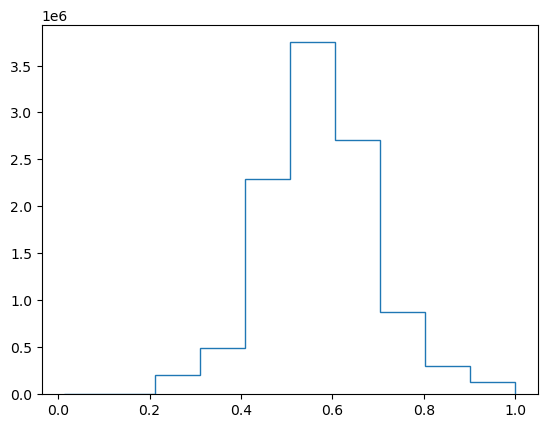

In [22]:
import matplotlib.pyplot as plt

counts, bins = np.histogram(similarities)
plt.stairs(counts, bins)

## Strategy 1: looking for similar compounds in a big commercial dataset

In [26]:
# Download the Asinex library of March 11, 2025
#url = "https://raw.githubusercontent.com/UAMCAntwerpen/2040FBDBIC/master/assets/databases/notebook-4/asinex_11march2025.smi"
#lines = requests.get(url).text.split("\n")
#print(len(lines))

asinex_smiles = []
asinex_id = []
asinex_fp = []
asinex_npfp = []

with open("assets/databases/notebook-4/asinex_11march2025.smi", "r") as f: total_lines = sum(1 for _ in f)

with open("assets/databases/notebook-4/asinex_11march2025.smi", "r") as f:
    for LINE in tqdm(f, total=total_lines, desc="Processing SMILES"):
        LINE = LINE.strip()
        if LINE == "": continue

        FIELDS = LINE.split()
        if len(FIELDS) != 2: continue

        fp = smiles_to_fp(FIELDS[0])
        if fp is None or fp == "": continue

        np_fp = np.zeros((0,), dtype=np.int8)
        DataStructs.ConvertToNumpyArray(fp, np_fp)

        asinex_smiles.append(FIELDS[0])
        asinex_id.append(FIELDS[1])
        asinex_fp.append(fp)
        asinex_npfp.append(np_fp)

print(len(asinex_fp), len(asinex_npfp), len(asinex_id), len(asinex_smiles))

Processing SMILES:   0%|          | 0/646891 [00:00<?, ?it/s]

646891 646891 646891 646891


In [27]:
total = len(asinex_fp) * len(chembl_fp)

SIMILARITY_HITS_fp = []
SIMILARITY_HITS_idx = []

CUTOFF = 0.8

for idx, fp in enumerate(tqdm(asinex_fp, desc="Bulk similarity")):
    sims = DataStructs.BulkTanimotoSimilarity(fp, chembl_fp)
    if any(CUTOFF < s < 1.0 for s in sims):
        SIMILARITY_HITS_fp.append(fp)
        SIMILARITY_HITS_idx.append(idx)

Bulk similarity:   0%|          | 0/646891 [00:00<?, ?it/s]

In [28]:
print(len(SIMILARITY_HITS_fp))

1466


## Strategy 2: Building a classification model that is applied to the Asinex set

In [32]:
# For this we assume that the CHEMBL_HITS contains all actives
# We need to create a decoy set with inactives: we can take a random sample from the Asinex for this
import random

decoy_npfp = [asinex_npfp[random.randint(0, len(asinex_npfp) - 1)] for _ in range(len(chembl_npfp))]
print(len(decoy_npfp))

4640


In [35]:
# Now we need to prepare the data for model building.
# We need a list with fps, and a second list with the activity class (1 = active, 0 = inactive)
npfp = []
activities = []
for i in chembl_npfp:
    npfp.append(i)
    activities.append(1)
for i in decoy_npfp:
    npfp.append(i)
    activities.append(0)

print(len(activities), len(npfp))

9280 9280


In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

act_train, act_test, fps_train, fps_test = train_test_split(activities, npfp, test_size=0.3)
model = RandomForestClassifier(max_depth=2)
model.fit(fps_train, act_train)

,n_estimators,100
,criterion,'gini'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [42]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score

prediction = model.predict(fps_test)
print(accuracy_score(act_test, prediction))

0.944683908045977


In [45]:
# Apply the model to the entire asinex library 
prediction = model.predict(asinex_npfp)

RF_HITS_fp = []
RF_HITS_idx = []

for i in range(len(prediction)):
    if prediction[i] == 1:
        RF_HITS_fp.append(asinex_fp[i])
        RF_HITS_idx.append(i)

print(len(RF_HITS_fp))

27154


## A more complicated model: a neural network

In [46]:
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(max_iter=500, random_state=42))
])

act_train, act_test, fps_train, fps_test = train_test_split(activities, npfp, test_size=0.3)
model = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(max_iter=500,
                          random_state=42,
                          activation='tanh',
                          alpha=0.005, 
                          batch_size=64,
                          hidden_layer_sizes=(512, 256),
                          learning_rate_init=0.001))])
model.fit(fps_train, act_train)
predictions = model.predict(fps_test)
print(roc_auc_score(act_test, predictions))

0.9938677696870348


In [48]:
# Apply the model to the entire asinex library 
prediction = model.predict(asinex_npfp)

NN_HITS_fp = []
NN_HITS_idx = []

for i in range(len(prediction)):
    if prediction[i] == 1:
        NN_HITS_fp.append(asinex_fp[i])
        NN_HITS_idx.append(i)

print(len(NN_HITS_fp))

4764


## A SVC model

In [49]:
from sklearn.svm import SVC

# Split data
act_train, act_test, fps_train, fps_test = train_test_split(activities, npfp, test_size=0.3)

# Create model
model = SVC(
    kernel="rbf",        # radial basis function (default)
    C=1.0,               # regularization
    gamma="scale",       # kernel coefficient
    probability=True,    # needed for ROC AUC
    random_state=42
)

# Train
model.fit(fps_train, act_train)
predictions = model.predict(fps_test)
print(roc_auc_score(act_test, predictions))

0.9950083606989844


In [50]:
# Apply the model to the entire asinex library 
prediction = model.predict(asinex_npfp)

SVC_HITS_fp = []
SVC_HITS_idx = []

for i in range(len(prediction)):
    if prediction[i] == 1:
        SVC_HITS_fp.append(asinex_fp[i])
        SVC_HITS_idx.append(i)

print(len(SVC_HITS_fp))

845


## Now combine all HITS and write to a file

In [55]:
# First make sure that we remove duplicates
idx_set = set(SIMILARITY_HITS_idx) | set(RF_HITS_idx) | set(NN_HITS_idx) | set(SVC_HITS_idx)
print(len(idx_set))
print(len(SIMILARITY_HITS_idx) + len(RF_HITS_idx) + len(NN_HITS_idx) + len(SVC_HITS_idx))

30755
34229


In [58]:
mols = []
for i in idx_set:
    smiles = asinex_smiles[i]
    code = asinex_id[i]
    mol = Chem.MolFromSmiles(smiles)
    mol.SetProp("_Name", code)
    mol_h = Chem.AddHs(mol)
    status = AllChem.EmbedMolecule(mol_h, AllChem.ETKDGv3())
    if status == 0:
        # Optional geometry optimization
        AllChem.MMFFOptimizeMolecule(mol_h)
        mols.append(mol_h)

[16:21:42] UFFTYPER: Unrecognized atom type: S_5+6 (1)
[16:21:53] UFFTYPER: Unrecognized atom type: Ru5 (29)
[16:21:53] UFFTYPER: Warning: hybridization set to SP3 for atom 39
[16:31:55] UFFTYPER: Unrecognized atom type: Ni6+2 (26)
[16:31:55] UFFTYPER: Unrecognized atom type: Cu6+1 (26)
[16:31:56] UFFTYPER: Unrecognized atom type: Cu6+1 (26)


In [60]:
# Write to sdf
writer = Chem.SDWriter("scratch/hits_from_classification_models.sdf")

# Write molecules
for mol in mols:
    if mol is not None: writer.write(mol)

# Close file
writer.close()

# Finished?

For those that are interested in machine learning for drug discovery, this paper provides an excellent review of the current state-of-the-art on this topic:

- <a href="assets/pdf/Machine-learning-in-drug-discovery-a-review.pdf" download>Machine learning in drug discovery: a review</a>

When finished, it is time to move to the fifth notebook of this course. In this notebook, you will translate the three-dimensional structure of the MDM2-p53 complex into a pharmacophore, and use it to refine the compound database that you have just built:

- [Notebook 5: Pharmacophore searching](Notebook-5-pharmacophore-searching.ipynb)